# **Importing Data**, **Libraries**, & **Initial Checks**

In [ ]:
# Installing and importing libraries
install.packages("googledrive")
install.packages("readr")
install.packages("plotly")
install.packages("dplyr")
install.packages("tidyr")
install.packages("factoextra")
install.packages("FactoMineR")
install.packages("cluster")
install.packages("clValid")
install.packages("NbClust")

library(googledrive)
library(readr)
library(dplyr)
library(tidyr)
library(cluster)
library(factoextra)
library(FactoMineR)
library(cluster)
library(ggplot2)
library(plotly)
library(dplyr)
library(clValid)
library(NbClust)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘lazyeval’, ‘crosstalk’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘rbibutils’, ‘Deriv’, ‘microbenchmark’, ‘Rdpack’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘estimability’, ‘mvtnorm’, ‘numDeriv’, ‘corrplot’, ‘viridis’, ‘car’, ‘DT’, ‘ellipse’, ‘emmeans’, ‘flashClust’, ‘leaps’, ‘multcompView’, ‘scatterplot3d’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘gridExtra’, ‘polynom’, ‘rstatix’, ‘plyr

In [ ]:
drive_auth()
drive_ls()
drive_download(file = "Colab Notebooks/ML I - Final Project/train.csv", overwrite = TRUE)

The googledrive package is requesting access to your Google account.
Enter '1' to start a new auth process or select a pre-authorized account.
1: Send me to the browser for a new auth process.
2: senath.d19@gmail.com


Selection: 1


Please point your browser to the following url: 

https://accounts.google.com/o/oauth2/v2/auth?client_id=603366585132-frjlouoa3s2ono25d2l9ukvhlsrlnr7k.apps.googleusercontent.com&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email&redirect_uri=https%3A%2F%2Fwww.tidyverse.org%2Fgoogle-callback%2F&response_type=code&state=55a65b5ee8ce854c408930b5e138f6b1&access_type=offline&prompt=consent



Enter authorization code: eyJjb2RlIjoiNC8wQWIzMmo5MXNBeU9aNGhMQUhlOEQ5c1NSR21pYnRNejE0X2xPY0RaRmE2UkhfWnZoZ0t1NUQ4MlV5dEZhVEFIOVRGdS1NZyIsInN0YXRlIjoiNTVhNjViNWVlOGNlODU0YzQwODkzMGI1ZTEzOGY2YjEifQ==


ERROR while rich displaying an object: Error in rbind(parts$upper, chars$ellip_v, parts$lower, deparse.level = 0L): number of columns of matrices must match (see arg 3)

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         retu

In [ ]:
# Importing the data
train <- read_csv("train.csv")

Rows: 7735 Columns: 16
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (5): Gender, Workout Type, Workout Intensity, Mood Before Workout, Mood...
dbl (11): Age, Height (cm), Weight (kg), Workout Duration (mins), Calories B...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
# Load and prepare data
df <- train

In [ ]:
# Checking the shape of the dataset
dim(df)

[1] 7735   16

In [ ]:
# Check for duplicate rows
duplicate_rows <- duplicated(df)
num_duplicate_rows <- sum(duplicate_rows)

if (num_duplicate_rows > 0) {
  print(paste("Number of duplicate rows found:", num_duplicate_rows))

  # Display the duplicate rows
  display(df[duplicate_rows, ])
} else {
  print("No duplicate rows found")
}

[1] "No duplicate rows found"




---



# **Discriptive Analysis**: Part 2

In [ ]:
# Select features for FAMD - mixed types
categorical_features <- c('Gender', 'Workout Type', 'Workout Intensity', 'Mood Before Workout', 'Mood After Workout')
numerical_features <- c('Age', 'Height (cm)', 'Weight (kg)', 'Workout Duration (mins)', 'Calories Burned', 'Heart Rate (bpm)',
                        'Steps Taken', 'Distance (km)', 'Sleep Hours', 'Daily Calories Intake', 'Resting Heart Rate (bpm)')

# Add some engineered features if available
# engineered_features <- c()
# if('rolling_mean_24h' %in% names(df)) engineered_features <- c(engineered_features, 'rolling_mean_24h')

famd_features <- c(categorical_features, numerical_features)

# Convert categorical features to factors and ensure unique levels across features
for(feature in categorical_features) {
  if(feature %in% names(df)) {
    df[[feature]] <- as.factor(df[[feature]])
    # Prefix the feature name to each level to make them unique
    levels(df[[feature]]) <- paste(feature, levels(df[[feature]]), sep = "_")
  }
}

# Prepare data again
X_famd <- df[, famd_features]

# Remove constant features
constant_features <- sapply(X_famd, function(x) length(unique(x)) <= 1)
X_famd <- X_famd[, !constant_features]

print(paste("Features for FAMD:", length(famd_features)))
print(paste("Categorical:", length(categorical_features)))
print(paste("Numerical:", length(numerical_features)))
# print(paste("Engineered:", length(engineered_features)))


# Ensure unique row names
rownames(X_famd) <- make.unique(as.character(1:nrow(X_famd)))

# Perform FAMD
print("Performing FAMD...")
famd_result <- FAMD(X_famd, ncp = 10, graph = FALSE)

# FAMD Summary
print("FAMD Results Summary:")
summary(famd_result)

[1] "Features for FAMD: 16"
[1] "Categorical: 5"
[1] "Numerical: 11"


Warning message:
“Setting row names on a tibble is deprecated.”


[1] "Performing FAMD..."
[1] "FAMD Results Summary:"

Call:
FAMD(base = X_famd, ncp = 10, graph = FALSE) 


Eigenvalues
                      Dim.1  Dim.2  Dim.3  Dim.4  Dim.5  Dim.6  Dim.7  Dim.8
Variance              1.100  1.075  1.070  1.064  1.054  1.047  1.038  1.031
% of var.             4.401  4.300  4.279  4.256  4.218  4.190  4.154  4.125
Cumulative % of var.  4.401  8.701 12.980 17.236 21.454 25.644 29.797 33.922
                      Dim.9 Dim.10
Variance              1.021  1.014
% of var.             4.085  4.054
Cumulative % of var. 38.007 42.062

Individuals (the 10 first)
                                             Dist    Dim.1    ctr   cos2  
1                                        |  4.467 | -1.605  0.030  0.129 |
2                                        |  5.250 |  1.741  0.036  0.110 |
3                                        |  5.006 | -1.881  0.042  0.141 |
4                                        |  4.858 | -0.264  0.001  0.003 |
5                            



---



* **Part 1**: FAMD **Visualization**

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
“Ignoring empty aesthetic: `width`.”
ERROR while rich displaying an object: Error in `scale_color_viridis_c()`:
! Discrete value supplied to a continuous scale.
ℹ Example values: "Calories Burned".

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", m

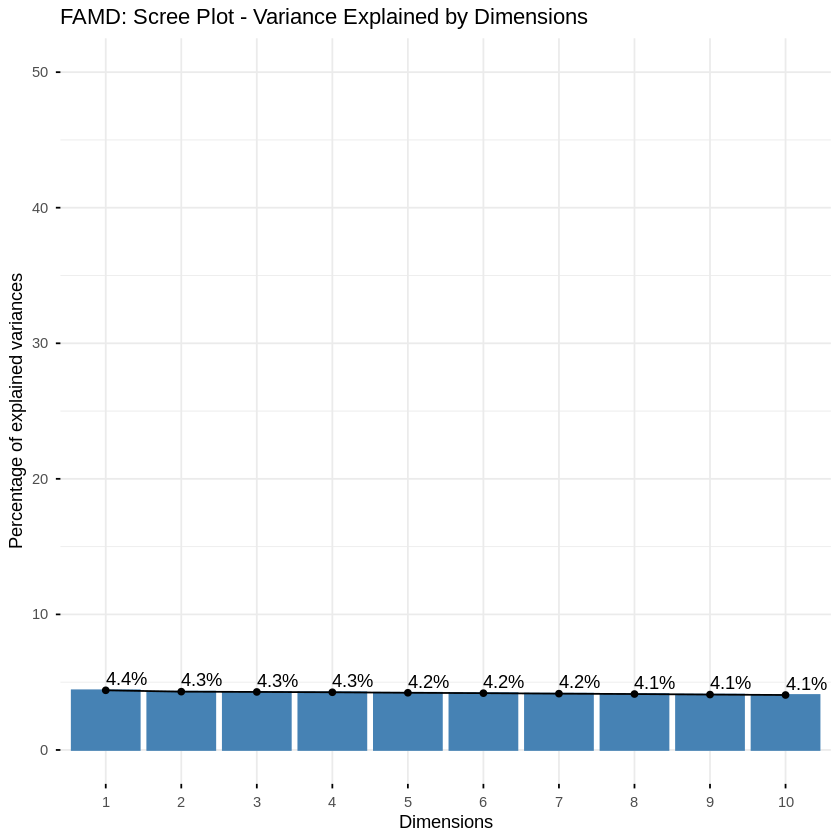

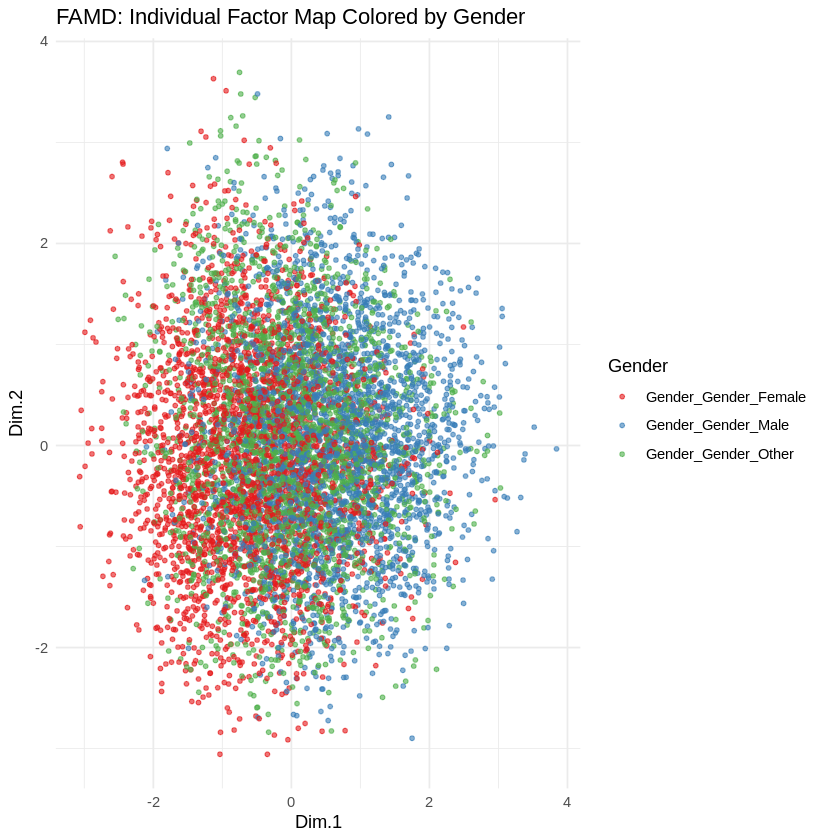

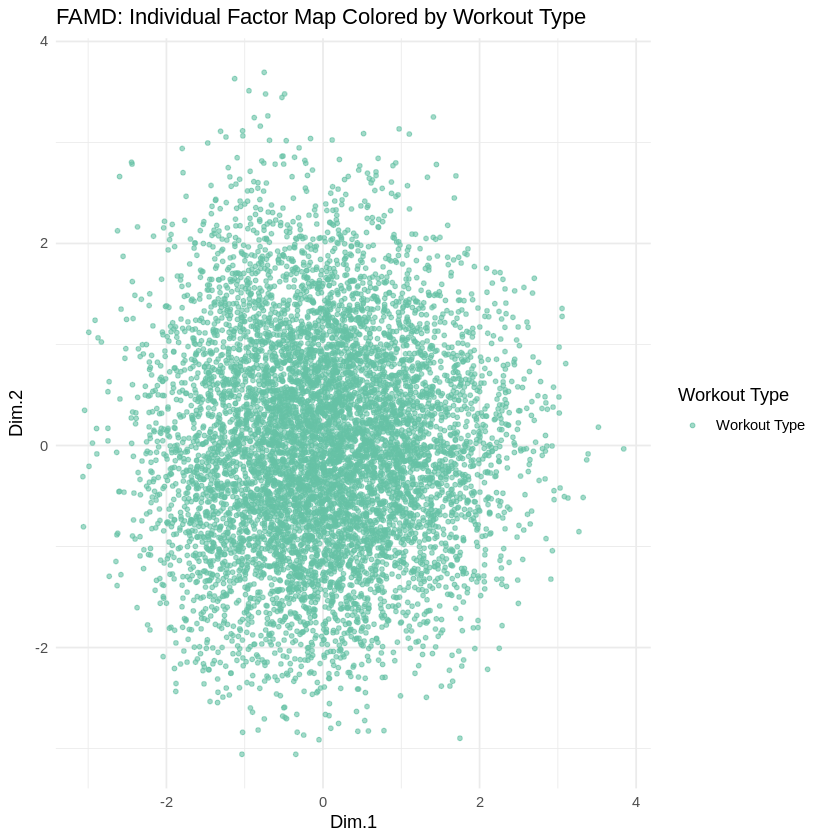

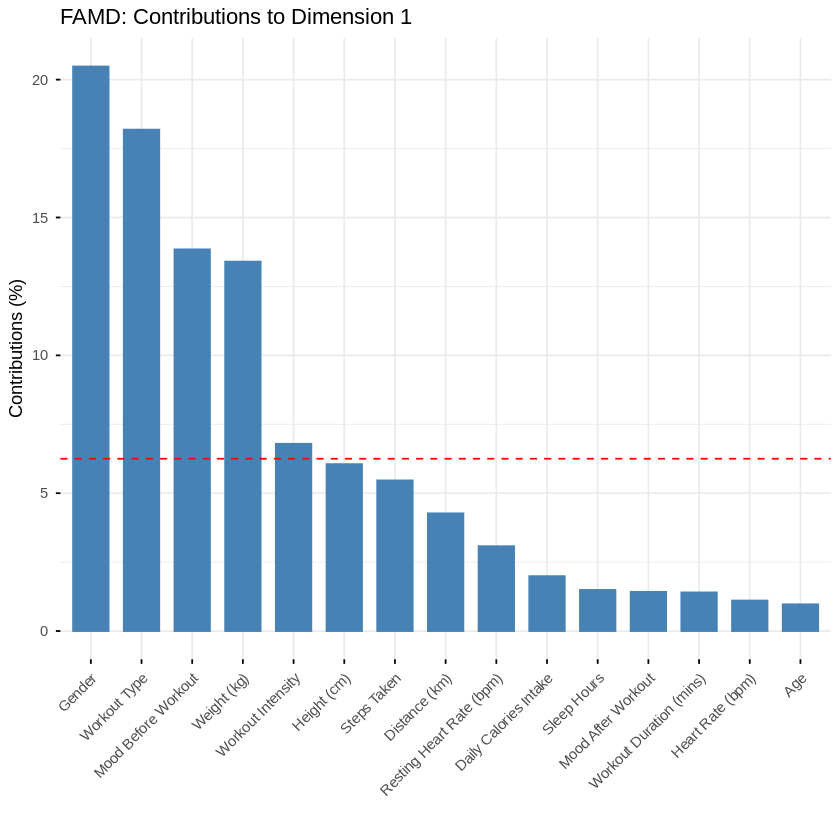

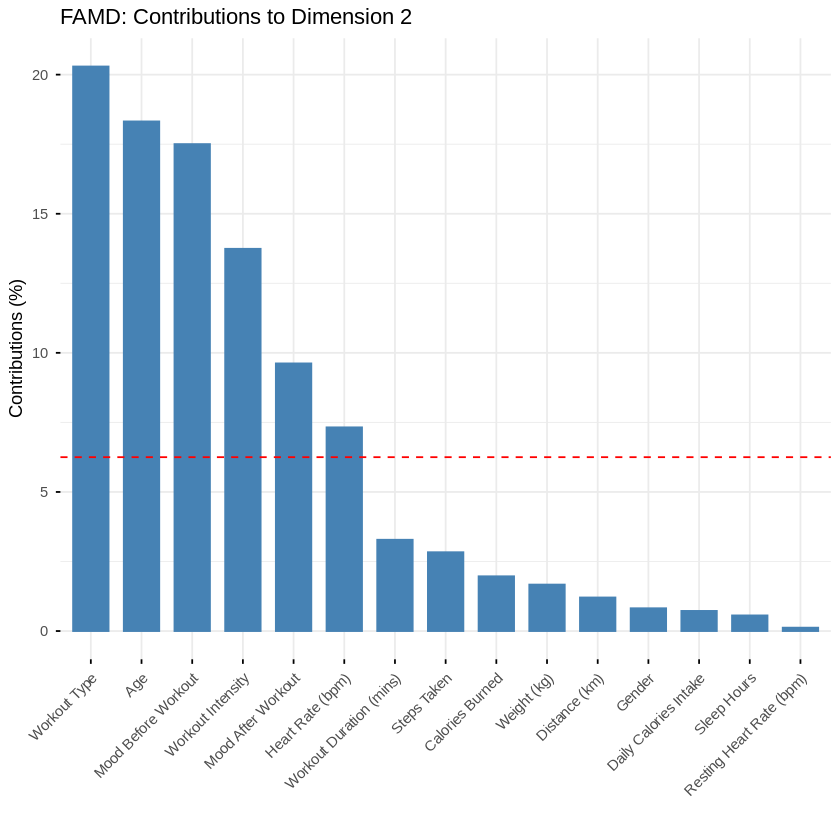

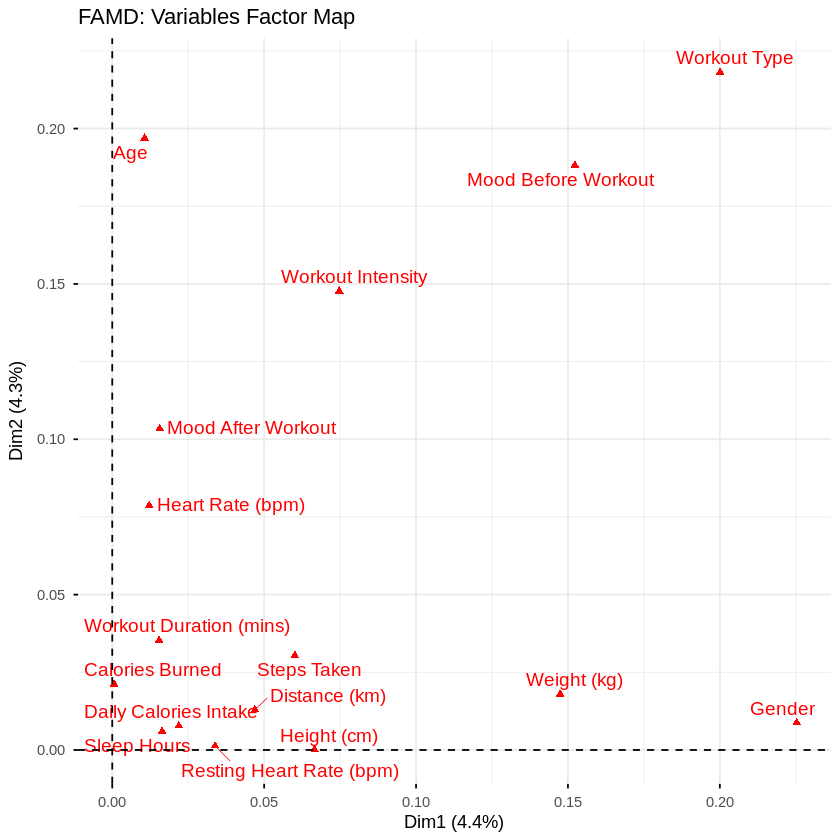

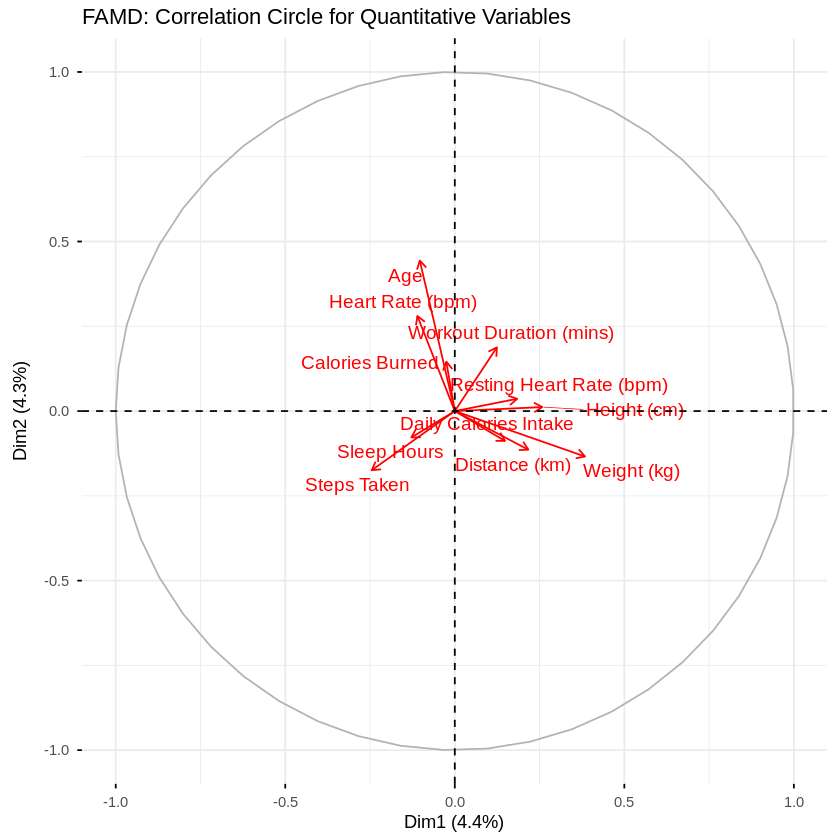

[1] "Top contributing variables to Dimension 1:"
                  Gender             Workout Type      Mood Before Workout 
               20.477167                18.187066                13.843688 
             Weight (kg)        Workout Intensity              Height (cm) 
               13.400077                 6.791310                 6.054077 
             Steps Taken            Distance (km) Resting Heart Rate (bpm) 
                5.463134                 4.269015                 3.076831 
   Daily Calories Intake 
                1.991158 
[1] "Top contributing variables to Dimension 2:"
           Workout Type                     Age     Mood Before Workout 
              20.293204               18.319082               17.503847 
      Workout Intensity      Mood After Workout        Heart Rate (bpm) 
              13.740468                9.620511                7.322182 
Workout Duration (mins)             Steps Taken         Calories Burned 
               3.281749      

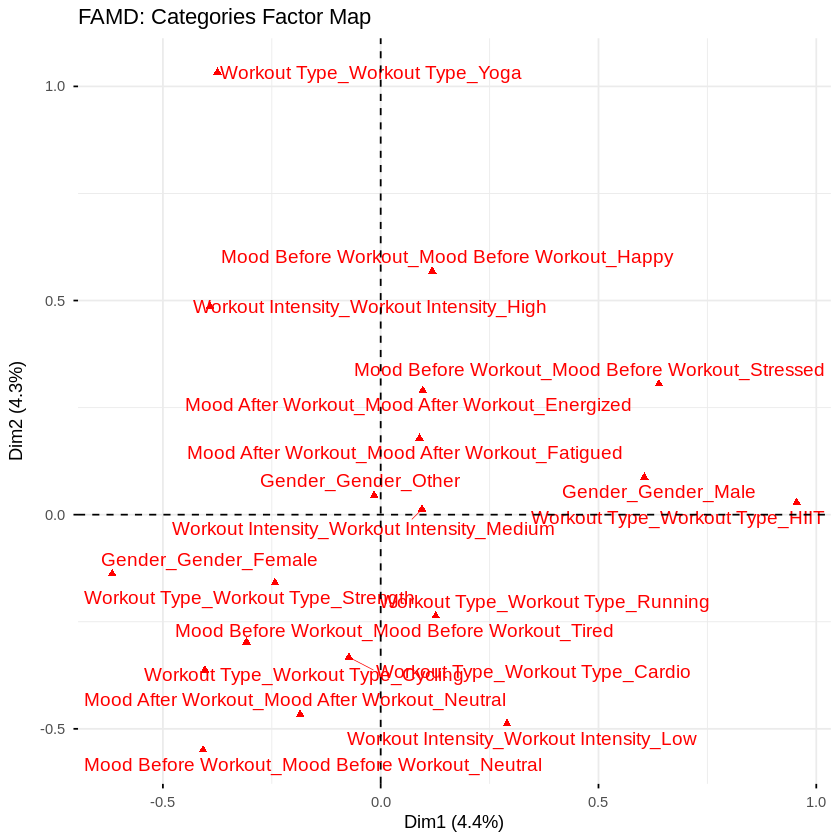

In [ ]:
# 1. Eigenvalues and Variance Explained
fviz_screeplot(famd_result, addlabels = TRUE, ylim = c(0, 50)) +
  ggtitle("FAMD: Scree Plot - Variance Explained by Dimensions")

# 2. Individual Factor Map colored by bike Calories Burned
famd_scores <- as.data.frame(famd_result$ind$coord)
famd_scores$'Calories Burned' <- df$'Calories Burned'

ggplot(famd_scores, aes(x = Dim.1, y = Dim.2, color = 'Calories Burned')) +
  geom_point(alpha = 0.6, size = 1) +
  scale_color_viridis_c(name = "Calories Burned") +
  ggtitle("FAMD: Individual Factor Map Colored by Calories Burned") +
  theme_minimal()

# 3. Factor Map colored by Gender
famd_scores$Gender <- as.factor(df$Gender)

ggplot(famd_scores, aes(x = Dim.1, y = Dim.2, color = Gender)) +
  geom_point(alpha = 0.6, size = 1) +
  scale_color_brewer(palette = "Set1", name = "Gender") +
  ggtitle("FAMD: Individual Factor Map Colored by Gender") +
  theme_minimal()

# 4. Factor Map colored by Workout Type
famd_scores$'Workout Type' <- as.factor(df$'Workout Type')

ggplot(famd_scores, aes(x = Dim.1, y = Dim.2, color = 'Workout Type')) +
  geom_point(alpha = 0.6, size = 1) +
  scale_color_brewer(palette = "Set2", name = "Workout Type") +
  ggtitle("FAMD: Individual Factor Map Colored by Workout Type") +
  theme_minimal()

# 5. Variable Contributions
# Quantitative variables
fviz_contrib(famd_result, choice = "var", axes = 1, top = 15) +
  ggtitle("FAMD: Contributions to Dimension 1")

fviz_contrib(famd_result, choice = "var", axes = 2, top = 15) +
  ggtitle("FAMD: Contributions to Dimension 2")

# 6. Biplot (simplified)
fviz_famd_var(famd_result, repel = TRUE) +
  ggtitle("FAMD: Variables Factor Map")

# 7. Correlation Circle for Quantitative Variables
fviz_famd_var(famd_result, choice = "quanti.var", repel = TRUE) +
  ggtitle("FAMD: Correlation Circle for Quantitative Variables")

# 8. Categories Factor Map
fviz_famd_var(famd_result, choice = "quali.var", repel = TRUE) +
  ggtitle("FAMD: Categories Factor Map")

# 9. Detailed variable analysis
print("Top contributing variables to Dimension 1:")
dim1_contrib <- sort(famd_result$var$contrib[,1], decreasing = TRUE)
print(head(dim1_contrib, 10))

print("Top contributing variables to Dimension 2:")
dim2_contrib <- sort(famd_result$var$contrib[,2], decreasing = TRUE)
print(head(dim2_contrib, 10))



---



* **Part 2**: **Cluster Analysis** using FAMD **Factor Scores**

In [ ]:
# Use first 10 dimensions for clustering (capture most variance, nearly 42%)
n_dims <- min(10, ncol(famd_result$ind$coord))
cluster_data <- famd_result$ind$coord[, 1:n_dims]

**Approach 1**: The **30** Different **Validation Criteria** (e.g., Calinski–Harabasz (CH), Dunn, Silhouette, SD index, Ball, Hartigan, etc.)

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 386750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 386750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 386750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 386750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 386750)”
Warning message:
“did not converge in 10 iterations”
Warning message:
“did not converge in 10 iterations”
Warning message:
“did not converge in 10 iterations”


*** : The Hubert index is a graphical method of determining the number of clusters.
                In the plot of Hubert index, we seek a significant knee that corresponds to a 
                significant increase of the value of the measure i.e the significant peak in Hubert
                index second differences plot. 
 


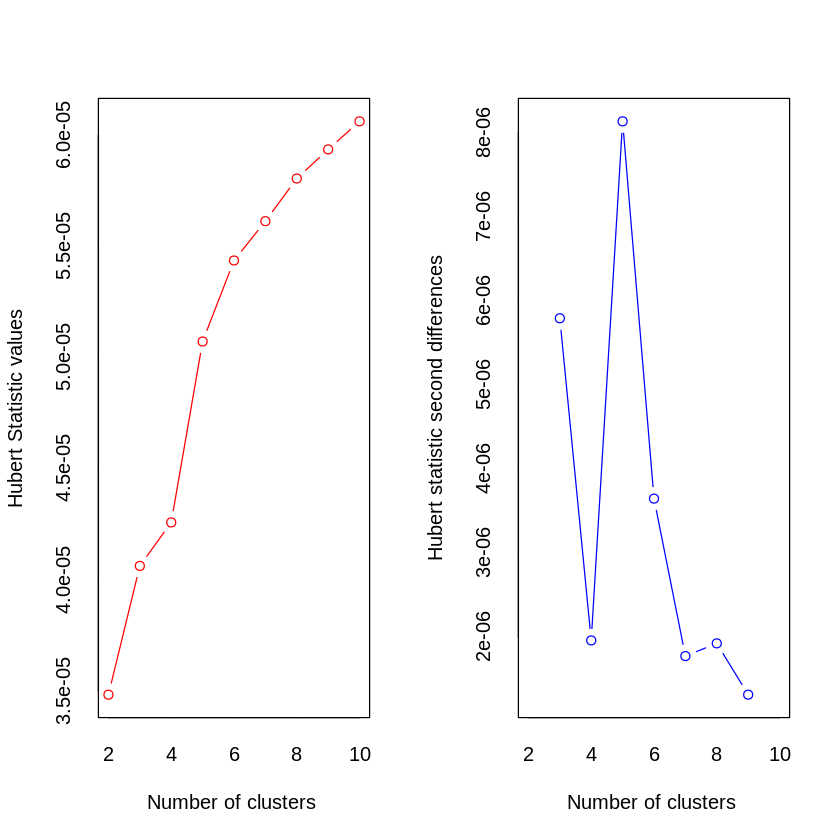

*** : The D index is a graphical method of determining the number of clusters. 
                In the plot of D index, we seek a significant knee (the significant peak in Dindex
                second differences plot) that corresponds to a significant increase of the value of
                the measure. 
 
******************************************************************* 
* Among all indices:                                                
* 5 proposed 2 as the best number of clusters 
* 1 proposed 3 as the best number of clusters 
* 1 proposed 4 as the best number of clusters 
* 7 proposed 5 as the best number of clusters 
* 3 proposed 6 as the best number of clusters 
* 2 proposed 8 as the best number of clusters 
* 4 proposed 10 as the best number of clusters 

                   ***** Conclusion *****                            
 
* According to the majority rule, the best number of clusters is  5 
 
 
******************************************************************* 


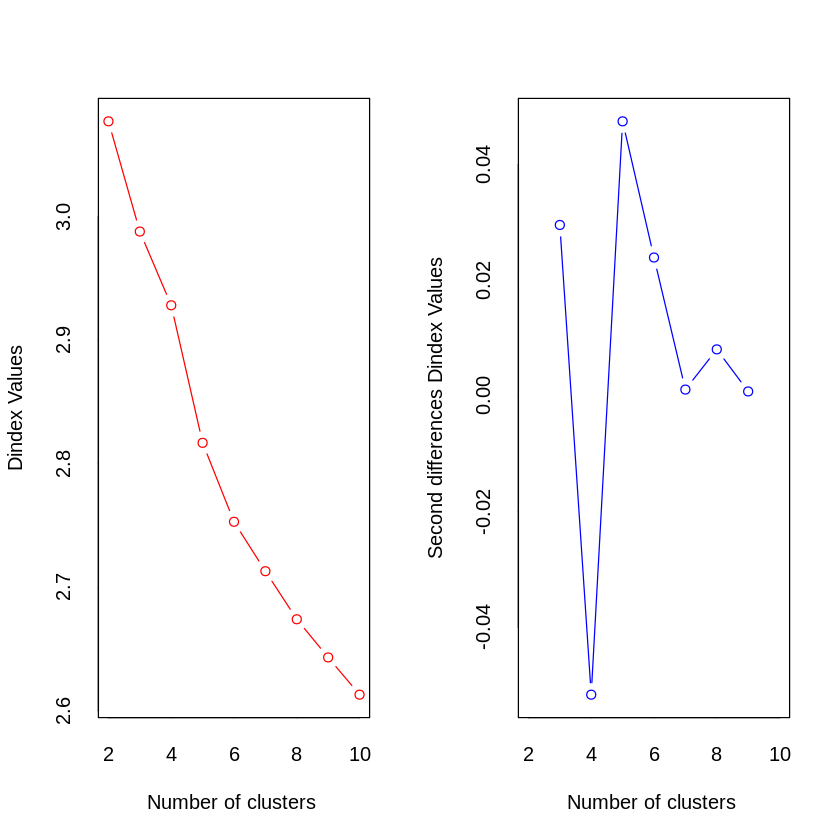

In [ ]:
nb <- NbClust(cluster_data, distance = "euclidean", min.nc = 2, max.nc = 10, method = "kmeans")

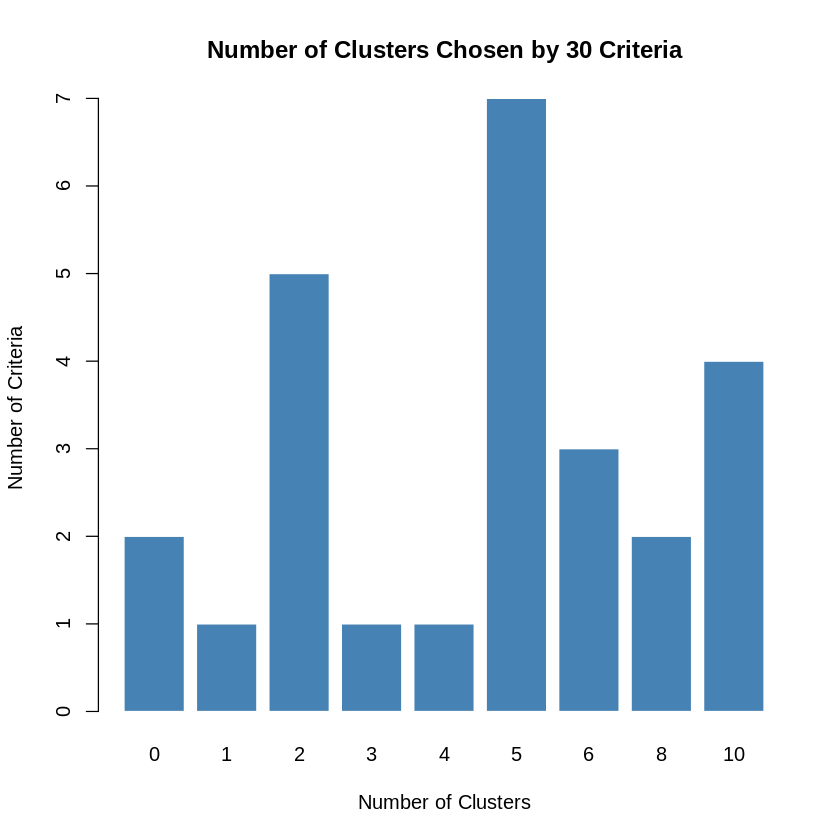

In [ ]:
barplot(table(nb$Best.n[1,]), xlab = "Number of Clusters", ylab = "Number of Criteria", main = "Number of Clusters Chosen by 30 Criteria", border = FALSE, col = "steelblue")



---



**Approach 2**: The **Elbow** Method

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 386750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 386750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 386750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 386750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 386750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 386750)”


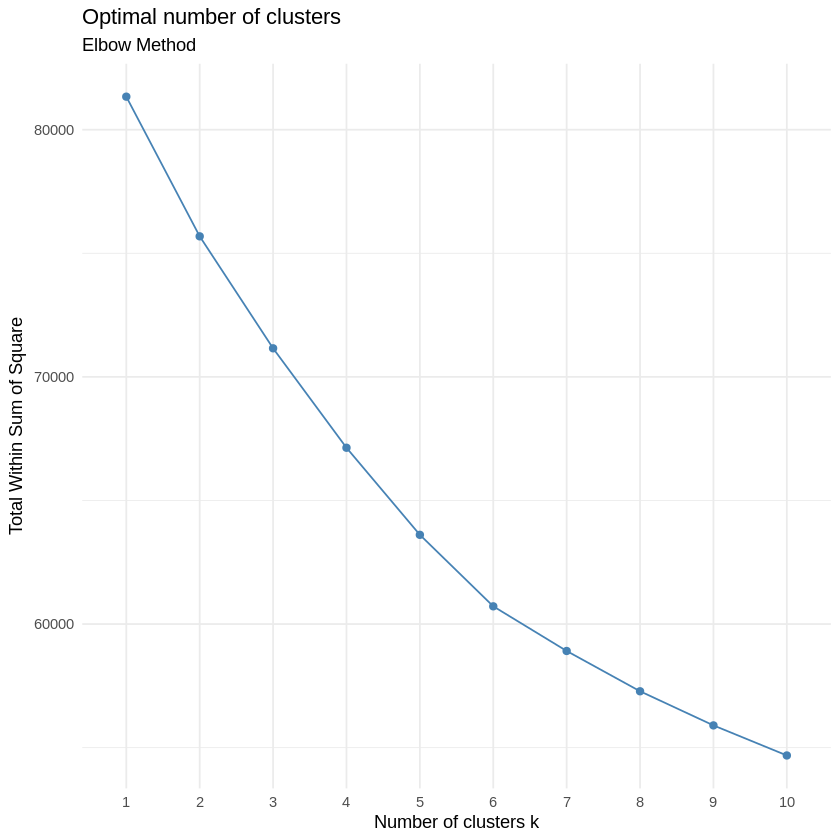

In [ ]:
custom_kmeans <- function(x, k) {
  set.seed(123)
  kmeans(x, centers = k, nstart = 25, iter.max = 100)
}

fviz_nbclust(cluster_data, FUNcluster = custom_kmeans, method = "wss") + labs(subtitle = "Elbow Method") + theme_minimal()



---



**Approach 3**: The **Silhouette** Method

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 386750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 386750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 386750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 386750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 386750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 386750)”


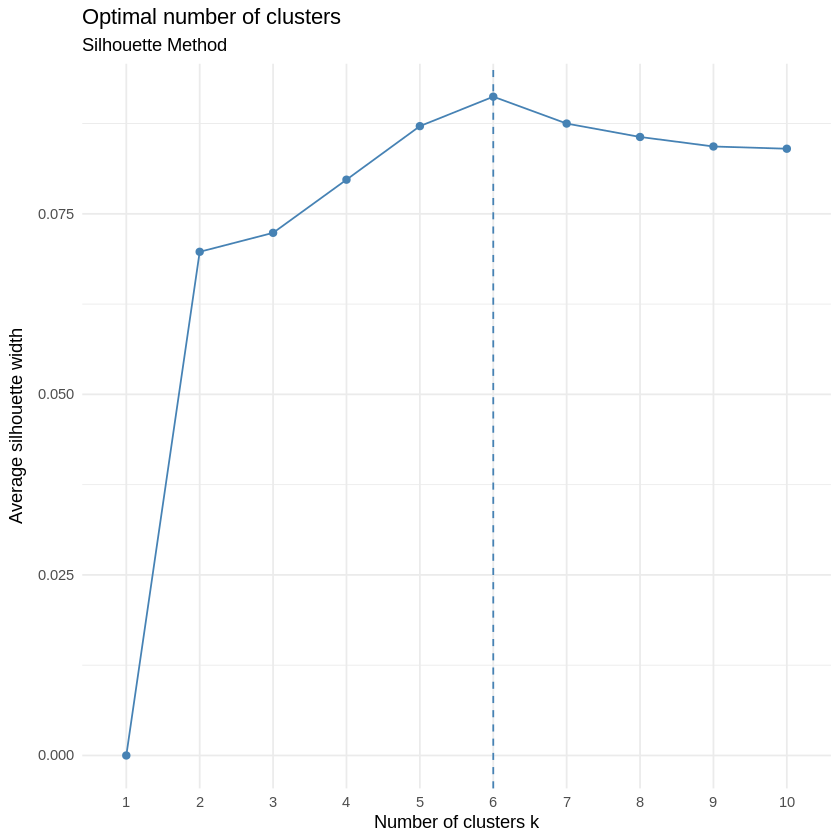

In [ ]:
fviz_nbclust(cluster_data, FUNcluster = custom_kmeans, method = "silhouette") + labs(subtitle = "Silhouette Method") + theme_minimal()



---



**Approach 4**: The **Gap Statistic** Method

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 386750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 386750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 386750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 386750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 386750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 386750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 386750)”


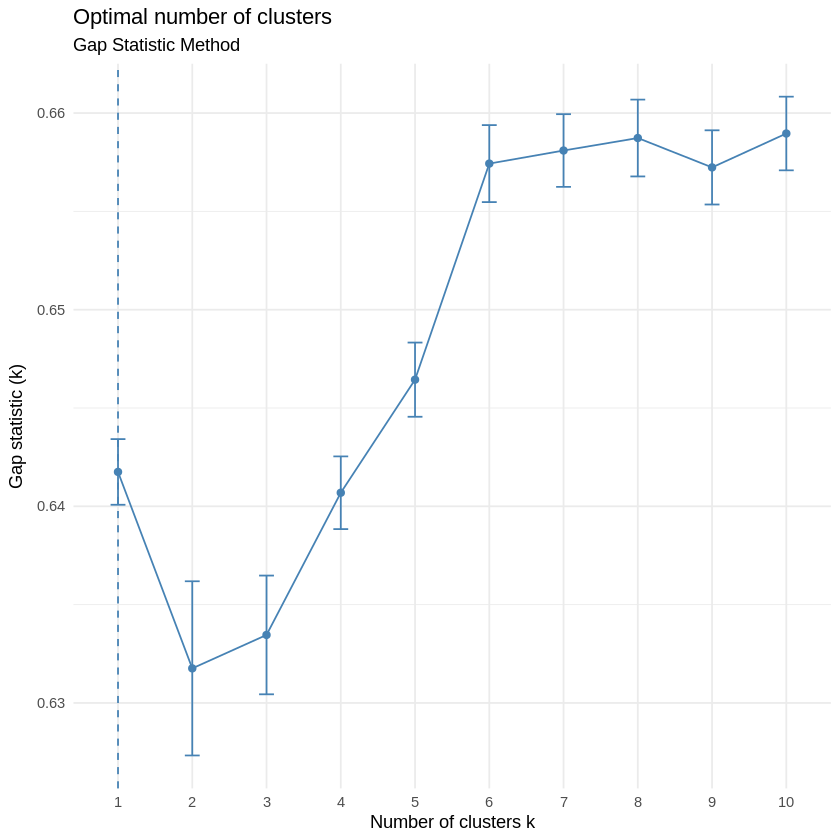

In [ ]:
set.seed(123)
fviz_nbclust(cluster_data, kmeans, method = "gap_stat", iter.max = 100, nboot = 100) + labs(subtitle = "Gap Statistic Method") + theme_minimal()



---



* **Part 3**: Final Clustering with **Optimal K**

In [ ]:
library(RColorBrewer)



Performing K-means clustering with K = 2 ...


Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 386750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 386750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 386750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 386750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 386750)”




📊 Analyzing cluster profiles...
# A tibble: 2 × 19
  cluster     n percentage avg_age avg_height avg_weight avg_duration
    <int> <int>      <dbl>   <dbl>      <dbl>      <dbl>        <dbl>
1       1  3320       42.9    38.6       176.       89.3         67.6
2       2  4415       57.1    38.0       173.       81.3         62.5
# ℹ 12 more variables: avg_calories_burned <dbl>, avg_heart_rate <dbl>,
#   avg_steps_taken <dbl>, avg_distance <dbl>, avg_sleep_hours <dbl>,
#   avg_daily_calories_intake <dbl>, avg_resting_heart_rate <dbl>,
#   dominant_gender <chr>, dominant_workout_type <chr>,
#   dominant_workout_intensity <chr>, dominant_mood_before <chr>,
#   dominant_mood_after <chr>


Performing K-means clustering with K = 5 ...


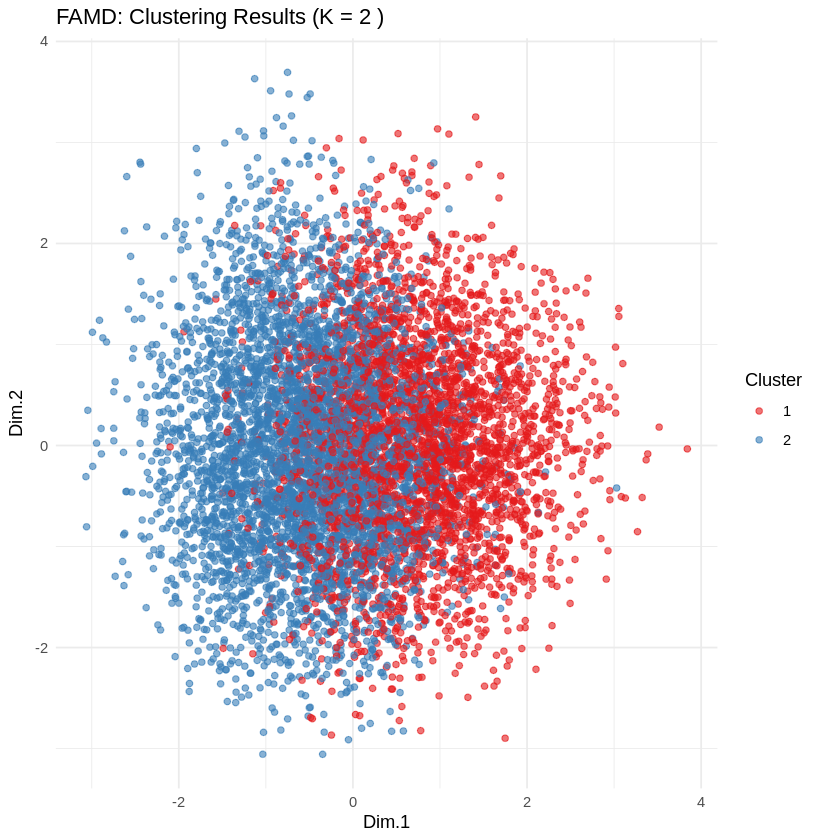



📊 Analyzing cluster profiles...
# A tibble: 5 × 19
  cluster     n percentage avg_age avg_height avg_weight avg_duration
    <int> <int>      <dbl>   <dbl>      <dbl>      <dbl>        <dbl>
1       2  2194       28.4    40.7       173.       82.4         63.6
2       5  1394       18.0    35.8       174.       83.5         66.8
3       3  1348       17.4    39.2       175.       84.9         73.6
4       1  1476       19.1    36.8       177.       88.3         62.5
5       4  1323       17.1    37.5       173.       85.8         57.6
# ℹ 12 more variables: avg_calories_burned <dbl>, avg_heart_rate <dbl>,
#   avg_steps_taken <dbl>, avg_distance <dbl>, avg_sleep_hours <dbl>,
#   avg_daily_calories_intake <dbl>, avg_resting_heart_rate <dbl>,
#   dominant_gender <chr>, dominant_workout_type <chr>,
#   dominant_workout_intensity <chr>, dominant_mood_before <chr>,
#   dominant_mood_after <chr>


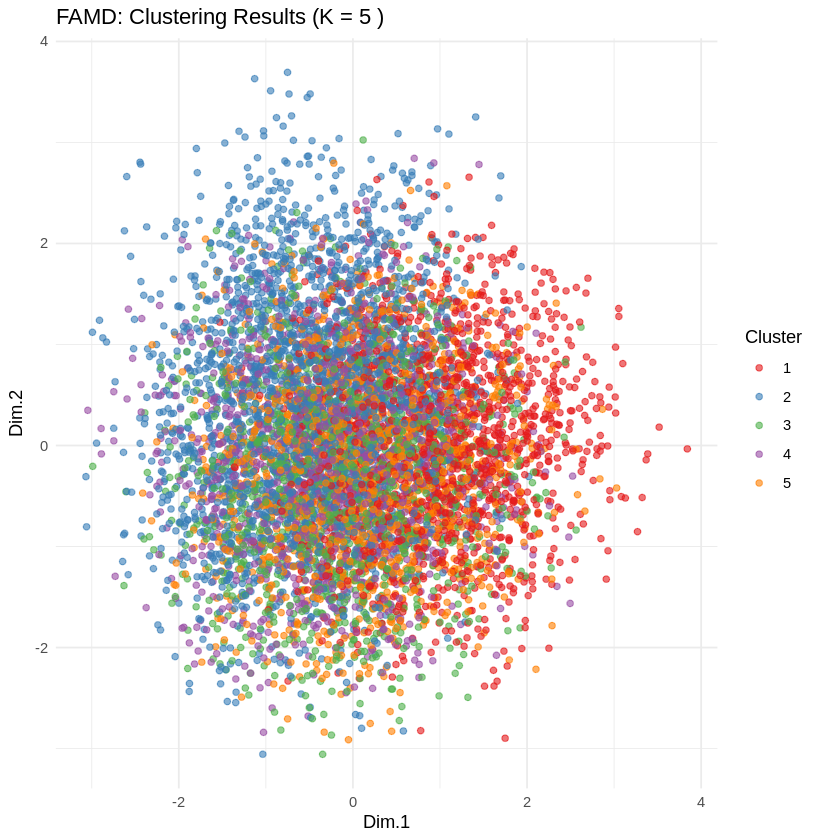

In [ ]:
perform_kmeans_analysis <- function(df, famd_result, k) {
  cat(paste("\n\nPerforming K-means clustering with K =", k, "...\n"))

  # Prepare FAMD score data
  famd_scores <- as.data.frame(famd_result$ind$coord)
  n_dims <- min(10, ncol(famd_scores)) # Use first 10 dimensions as previous
  cluster_data <- famd_scores[, 1:n_dims]


  # Run k-means
  set.seed(123)
  kmeans_result <- kmeans(cluster_data, centers = k, nstart = 25, iter.max = 500) # Increased iter.max

  # Add cluster labels
  df$cluster <- kmeans_result$cluster
  famd_scores$cluster <- as.factor(kmeans_result$cluster)

  # 2D Visualization of individuals colored by cluster
  p1 <- ggplot(famd_scores, aes(x = Dim.1, y = Dim.2, color = cluster)) +
    geom_point(alpha = 0.6, size = 1.5) +
    scale_color_brewer(palette = "Set1", name = "Cluster") +
    ggtitle(paste("FAMD: Clustering Results (K =", k, ")")) +
    theme_minimal()
  print(p1)

  # Cluster profiles
  cat("\n\n📊 Analyzing cluster profiles...\n")
  cluster_profiles <- df %>%
    group_by(cluster) %>%
    summarise(
      n = n(),
      percentage = n() / nrow(df) * 100,
      avg_age = mean(Age, na.rm = TRUE),
      avg_height = mean(`Height (cm)`, na.rm = TRUE),
      avg_weight = mean(`Weight (kg)`, na.rm = TRUE),
      avg_duration = mean(`Workout Duration (mins)`, na.rm = TRUE),
      avg_calories_burned = mean(`Calories Burned`, na.rm = TRUE),
      avg_heart_rate = mean(`Heart Rate (bpm)`, na.rm = TRUE),
      avg_steps_taken = mean(`Steps Taken`, na.rm = TRUE),
      avg_distance = mean(`Distance (km)`, na.rm = TRUE),
      avg_sleep_hours = mean(`Sleep Hours`, na.rm = TRUE),
      avg_daily_calories_intake = mean(`Daily Calories Intake`, na.rm = TRUE),
      avg_resting_heart_rate = mean(`Resting Heart Rate (bpm)`, na.rm = TRUE),
      dominant_gender = as.character(names(which.max(table(Gender)))),
      dominant_workout_type = as.character(names(which.max(table(`Workout Type`)))),
      dominant_workout_intensity = as.character(names(which.max(table(`Workout Intensity`)))),
      dominant_mood_before = as.character(names(which.max(table(`Mood Before Workout`)))),
      dominant_mood_after = as.character(names(which.max(table(`Mood After Workout`))))
    ) %>%
    arrange(desc(avg_calories_burned))

  print(cluster_profiles)


  return(list(
    model = kmeans_result,
    cluster_profiles = cluster_profiles,
    plots = list(p1 = p1) # Only include p1 as other plots depended on removed columns
  ))
}

# Run the function for K = 2 and K = 5 (based on previous analysis)
result_k1 <- perform_kmeans_analysis(df, famd_result, k = 2)
result_k2 <- perform_kmeans_analysis(df, famd_result, k = 5)



---



* **Part 4**: Cluster **Quality Validation**

In [ ]:
install.packages("fpc")
install.packages("clusterSim")

library(fpc)
library(clusterSim)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘modeltools’, ‘DEoptimR’, ‘mclust’, ‘flexmix’, ‘prabclus’, ‘diptest’, ‘robustbase’, ‘kernlab’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘pixmap’, ‘sp’, ‘RcppArmadillo’, ‘proxy’, ‘ade4’, ‘e1071’


Loading required package: MASS


Attaching package: ‘MASS’


The following object is masked from ‘package:plotly’:

    select


The following object is masked from ‘package:dplyr’:

    select




In [ ]:
evaluate_cluster_results <- function(df, famd_result, cluster_result, k) {
  cat(paste("\n\nEvaluating existing K-means clustering with K =", k, "...\n"))

  # Extract objects from previous results
  kmeans_result <- cluster_result$model
  famd_scores <- as.data.frame(famd_result$ind$coord)
  cluster_data <- famd_scores[, 1:min(5, ncol(famd_scores))]
  famd_scores$cluster <- as.factor(kmeans_result$cluster)
  df$cluster <- kmeans_result$cluster

  # Cluster Profile Summary
  vars_present <- names(df)

  cluster_profiles <- df %>%
    group_by(cluster) %>%
    summarise(
      n = n(),
      percentage = n() / nrow(df) * 100,
      avg_bikes = if ("cnt" %in% vars_present) mean(cnt, na.rm = TRUE) else NA,
      sd_bikes  = if ("cnt" %in% vars_present) sd(cnt, na.rm = TRUE) else NA,
      avg_temp  = if ("temp" %in% vars_present) mean(temp, na.rm = TRUE) else NA,
      avg_hum   = if ("hum" %in% vars_present) mean(hum, na.rm = TRUE) else NA,
      peak_hour = if ("hour" %in% vars_present) as.numeric(names(which.max(table(hour)))) else NA,
      dominant_season = if ("season" %in% vars_present) as.numeric(names(which.max(table(season)))) else NA,
      dominant_weather = if ("weathersit" %in% vars_present) as.numeric(names(which.max(table(weathersit)))) else NA
    )

  print(cluster_profiles)

  # Cluster Validation Metrics
  cat("\nPerforming cluster quality validation...\n")

  # 1. Silhouette
  sil <- silhouette(kmeans_result$cluster, dist(cluster_data))
  fviz_silhouette(sil) + ggtitle(paste("Silhouette Plot for K =", k))
  avg_sil_width <- mean(sil[, 3])
  cat(paste("Average Silhouette Width:", round(avg_sil_width, 3), "\n"))

  # 2. Calinski–Harabasz Index
  ch_index <- calinhara(cluster_data, kmeans_result$cluster)
  cat(paste("Calinski-Harabasz Index:", round(ch_index, 2), "\n"))

  # 3. Davies–Bouldin Index
  db_index <- index.DB(cluster_data, kmeans_result$cluster)$DB
  cat(paste("Davies-Bouldin Index:", round(db_index, 3), "\n"))

  # Cluster Stability (Bootstrap)
  cat("Performing cluster stability analysis (bootstrap)...\n")
  cluster_stability <- function(data, base_clusters, k, n_bootstrap = 10) {
    jaccard_similarities <- numeric(n_bootstrap)
    for(i in 1:n_bootstrap) {
      sample_indices <- sample(1:nrow(data), size = nrow(data) * 0.8, replace = TRUE)
      sample_data <- data[sample_indices, ]
      boot_clusters <- kmeans(sample_data, centers = k, nstart = 25)$cluster
      original_sample_clusters <- base_clusters[sample_indices]
      agreement <- mean(boot_clusters == original_sample_clusters)
      jaccard_similarities[i] <- agreement
    }
    mean(jaccard_similarities)
  }

  stability_score <- cluster_stability(cluster_data, kmeans_result$cluster, k)
  cat(paste("Cluster Stability Score:", round(stability_score, 3), "\n"))

  # Cluster Centers Visualization
  cluster_centers <- as.data.frame(kmeans_result$centers[, 1:2])

  # Assign cluster labels (1 to k)
  cluster_centers$cluster <- 1:k

  p1 <- ggplot() +
    geom_point(data = famd_scores, aes(x = Dim.1, y = Dim.2, color = cluster),
               alpha = 0.3, size = 1) +
    geom_point(data = cluster_centers, aes(x = Dim.1, y = Dim.2, fill = factor(cluster)),
               size = 5, shape = 23, color = "black") +
    scale_color_brewer(palette = "Set1", name = "Cluster") +
    scale_fill_brewer(palette = "Set1", name = "Cluster Center") +
    ggtitle(paste("FAMD Cluster Centers (K =", k, ")")) +
    theme_minimal()
  print(p1)

  # Return Results
  return(list(
    model = kmeans_result,
    sil_width = avg_sil_width,
    ch_index = ch_index,
    db_index = db_index,
    stability = stability_score,
    profiles = cluster_profiles,
    plots = list(cluster_center_plot = p1)
  ))
}

eval_k2 <- evaluate_cluster_results(df, famd_result, result_k1, k = 2)
eval_k4 <- evaluate_cluster_results(df, famd_result, result_k2, k = 5)